# 04 - Model Inference

This notebook demonstrates how to use the trained EEGNet model for inference on individual samples.

## Overview
- Load trained model
- Run inference on sample epochs
- Visualize prediction probabilities
- Compare predictions with ground truth
- Test model on custom data

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import torch
import torch.nn as nn

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from models.architectures.eegnet import EEGNet

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline


## 1. Load Configuration

In [2]:
# Load configuration
config_path = PROJECT_ROOT / "configs" / "config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Get class names
class_mapping = config['preprocessing']['class_mapping']
class_names = [class_mapping[i] for i in range(len(class_mapping))]

print(f"Classes: {class_names}")

Classes: ['left', 'right', 'down', 'up']


## 2. Load Trained Model

In [3]:
# Select subject
subject_idx = 0  # 0: k3b, 1: k6b, 2: l1b
subject_file = config['paths']['subjects'][subject_idx]
subject_id = Path(subject_file).stem

print(f"Loading model for subject: {subject_id}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load checkpoint
checkpoint_dir = PROJECT_ROOT / config['paths']['model_checkpoints']
checkpoint_path = checkpoint_dir / f"{subject_id}_best.pth"

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Model checkpoint not found: {checkpoint_path}\n"
        f"Train a model first using: 02_train_model.ipynb"
    )

checkpoint = torch.load(checkpoint_path, map_location=device)

# Create and load model
model = EEGNet(
    n_classes=config['model']['eegnet']['n_classes'],
    n_channels=config['model']['eegnet']['n_channels'],
    n_timepoints=config['model']['eegnet']['n_timepoints'],
    F1=config['model']['eegnet']['F1'],
    D=config['model']['eegnet']['D'],
    F2=config['model']['eegnet']['F2'],
    kernel_length=config['model']['eegnet']['kernel_length'],
    dropout=config['model']['eegnet']['dropout'],
    pool_size=config['model']['eegnet']['pool_size']
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"\nModel loaded successfully")
print(f"Trained on epoch {checkpoint['epoch']+1}")
print(f"Validation accuracy: {checkpoint['val_acc']:.4f}")

Loading model for subject: k3b
Using device: cpu

Model loaded successfully
Trained on epoch 77
Validation accuracy: 0.8889


## 3. Load Test Data

In [4]:
# Load validation data (for testing)
processed_dir = PROJECT_ROOT / config['paths']['processed_data']
val_file = processed_dir / f"{subject_id}_val.npz"

if not val_file.exists():
    raise FileNotFoundError(f"Validation data not found: {val_file}")

val_data = np.load(val_file)
X_val = val_data['X']
y_val = val_data['y']

print(f"Test data loaded: {X_val.shape}")
print(f"Labels: {y_val.shape}")

Test data loaded: (36, 60, 1001)
Labels: (36,)


## 4. Single Sample Inference

Run inference on individual samples and visualize predictions.

In [5]:
def predict_single_sample(model, sample, device):
    """
    Run inference on a single sample.
    
    Args:
        model: Trained EEGNet model
        sample: EEG data (n_channels, n_timepoints)
        device: torch device
    
    Returns:
        predicted_class: Predicted class index
        probabilities: Class probabilities
    """
    # Prepare input: (1, 1, n_channels, n_timepoints)
    input_tensor = torch.from_numpy(sample).float().unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1).cpu().numpy()[0]
        predicted_class = probabilities.argmax()
    
    return predicted_class, probabilities

In [6]:
# Select a random sample
sample_idx = np.random.randint(0, len(X_val))

sample = X_val[sample_idx]
true_label = y_val[sample_idx]

# Run prediction
predicted_class, probabilities = predict_single_sample(model, sample, device)

print(f"Sample {sample_idx}:")
print(f"  True label: {class_names[true_label]} (class {true_label})")
print(f"  Predicted:  {class_names[predicted_class]} (class {predicted_class})")
print(f"  Confidence: {probabilities[predicted_class]:.4f}")
print(f"\nClass probabilities:")
for i, (name, prob) in enumerate(zip(class_names, probabilities)):
    print(f"  {name}: {prob:.4f}")

Sample 28:
  True label: right (class 1)
  Predicted:  right (class 1)
  Confidence: 0.9807

Class probabilities:
  left: 0.0007
  right: 0.9807
  down: 0.0000
  up: 0.0186


## 5. Visualize Prediction

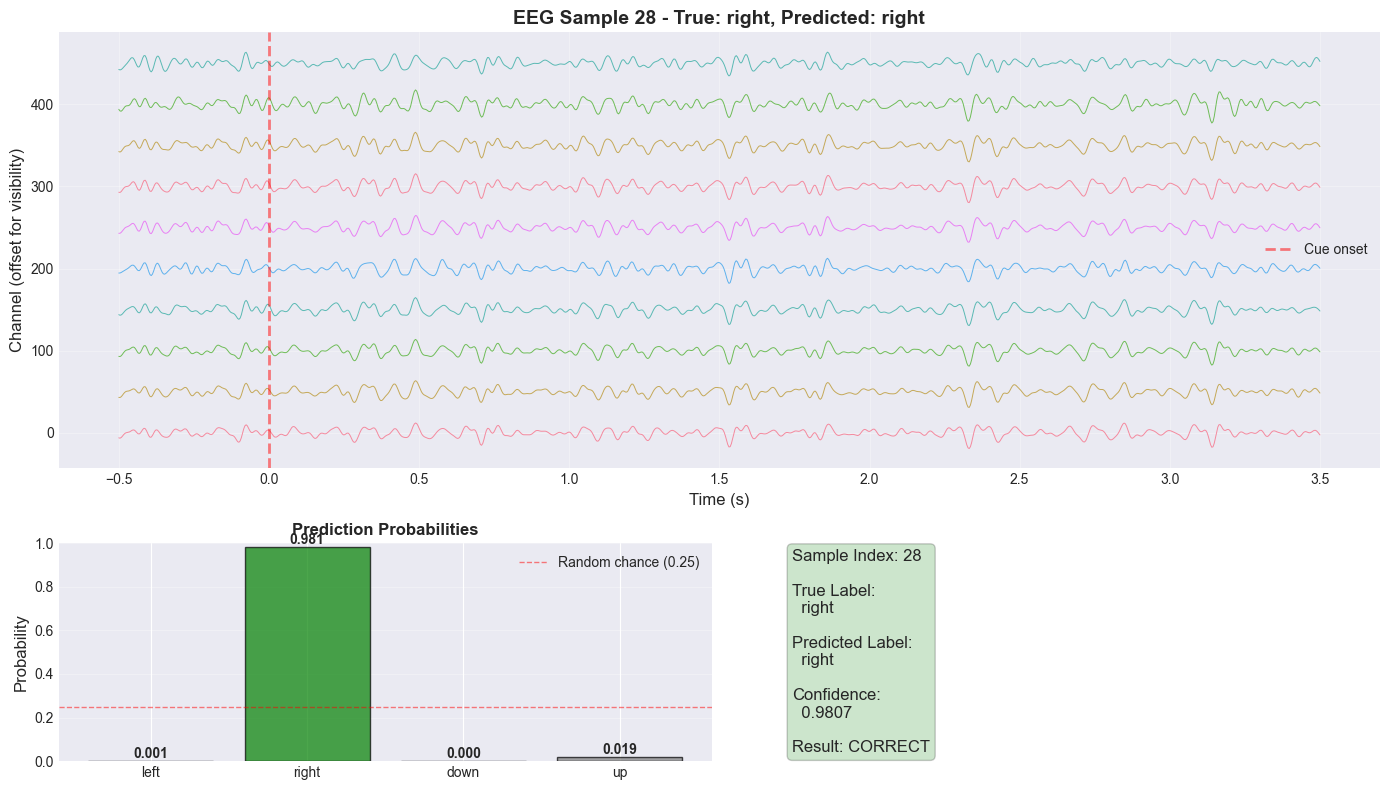

In [7]:
# Visualize the sample and prediction
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

# Plot EEG signals
ax1 = fig.add_subplot(gs[0, :])
time_axis = np.linspace(config['preprocessing']['epoch']['tmin'],
                        config['preprocessing']['epoch']['tmax'],
                        sample.shape[1])

# Plot first 10 channels
for ch_idx in range(min(10, sample.shape[0])):
    ax1.plot(time_axis, sample[ch_idx, :] + ch_idx * 50, 
            linewidth=0.7, alpha=0.8)

ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, 
           alpha=0.5, label='Cue onset')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Channel (offset for visibility)', fontsize=12)
ax1.set_title(f'EEG Sample {sample_idx} - True: {class_names[true_label]}, '
              f'Predicted: {class_names[predicted_class]}',
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot prediction probabilities
ax2 = fig.add_subplot(gs[1, 0])
colors = ['green' if i == predicted_class else 'gray' for i in range(len(class_names))]
bars = ax2.bar(class_names, probabilities, color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(y=0.25, color='red', linestyle='--', linewidth=1, 
           alpha=0.5, label='Random chance (0.25)')
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Prediction Probabilities', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1.0])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, prob in zip(bars, probabilities):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{prob:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Prediction summary
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')

result_text = f"Sample Index: {sample_idx}\n\n"
result_text += f"True Label:\n  {class_names[true_label]}\n\n"
result_text += f"Predicted Label:\n  {class_names[predicted_class]}\n\n"
result_text += f"Confidence:\n  {probabilities[predicted_class]:.4f}\n\n"

if predicted_class == true_label:
    result_text += "Result: CORRECT"
    color = 'green'
else:
    result_text += "Result: INCORRECT"
    color = 'red'

ax3.text(0.1, 0.5, result_text, fontsize=12, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))

plt.tight_layout()
plt.show()

## 6. Batch Inference

Run inference on multiple samples at once.

In [8]:
# Select multiple random samples
n_samples = 10
sample_indices = np.random.choice(len(X_val), n_samples, replace=False)

print(f"Running inference on {n_samples} samples...\n")

results = []
for idx in sample_indices:
    sample = X_val[idx]
    true_label = y_val[idx]
    
    predicted_class, probabilities = predict_single_sample(model, sample, device)
    
    results.append({
        'index': idx,
        'true': true_label,
        'predicted': predicted_class,
        'confidence': probabilities[predicted_class],
        'correct': predicted_class == true_label
    })

# Display results
print(f"{'Index':<8} {'True':<15} {'Predicted':<15} {'Confidence':<12} {'Result'}")
print("-" * 70)

for r in results:
    status = "CORRECT" if r['correct'] else "INCORRECT"
    print(f"{r['index']:<8} {class_names[r['true']]:<15} "
          f"{class_names[r['predicted']]:<15} {r['confidence']:<12.4f} {status}")

accuracy = sum(r['correct'] for r in results) / len(results)
print("-" * 70)
print(f"Accuracy: {accuracy:.2%} ({sum(r['correct'] for r in results)}/{len(results)})")

Running inference on 10 samples...

Index    True            Predicted       Confidence   Result
----------------------------------------------------------------------
27       up              up              0.5931       CORRECT
30       left            left            0.9747       CORRECT
2        right           right           0.9770       CORRECT
9        up              up              0.9823       CORRECT
4        right           right           0.9801       CORRECT
14       left            right           0.9663       INCORRECT
13       up              down            0.9784       INCORRECT
20       down            down            0.7951       CORRECT
7        down            down            0.9794       CORRECT
32       down            down            0.9881       CORRECT
----------------------------------------------------------------------
Accuracy: 80.00% (8/10)


## 7. Test on Specific Classes

Examine model performance on samples from each class.

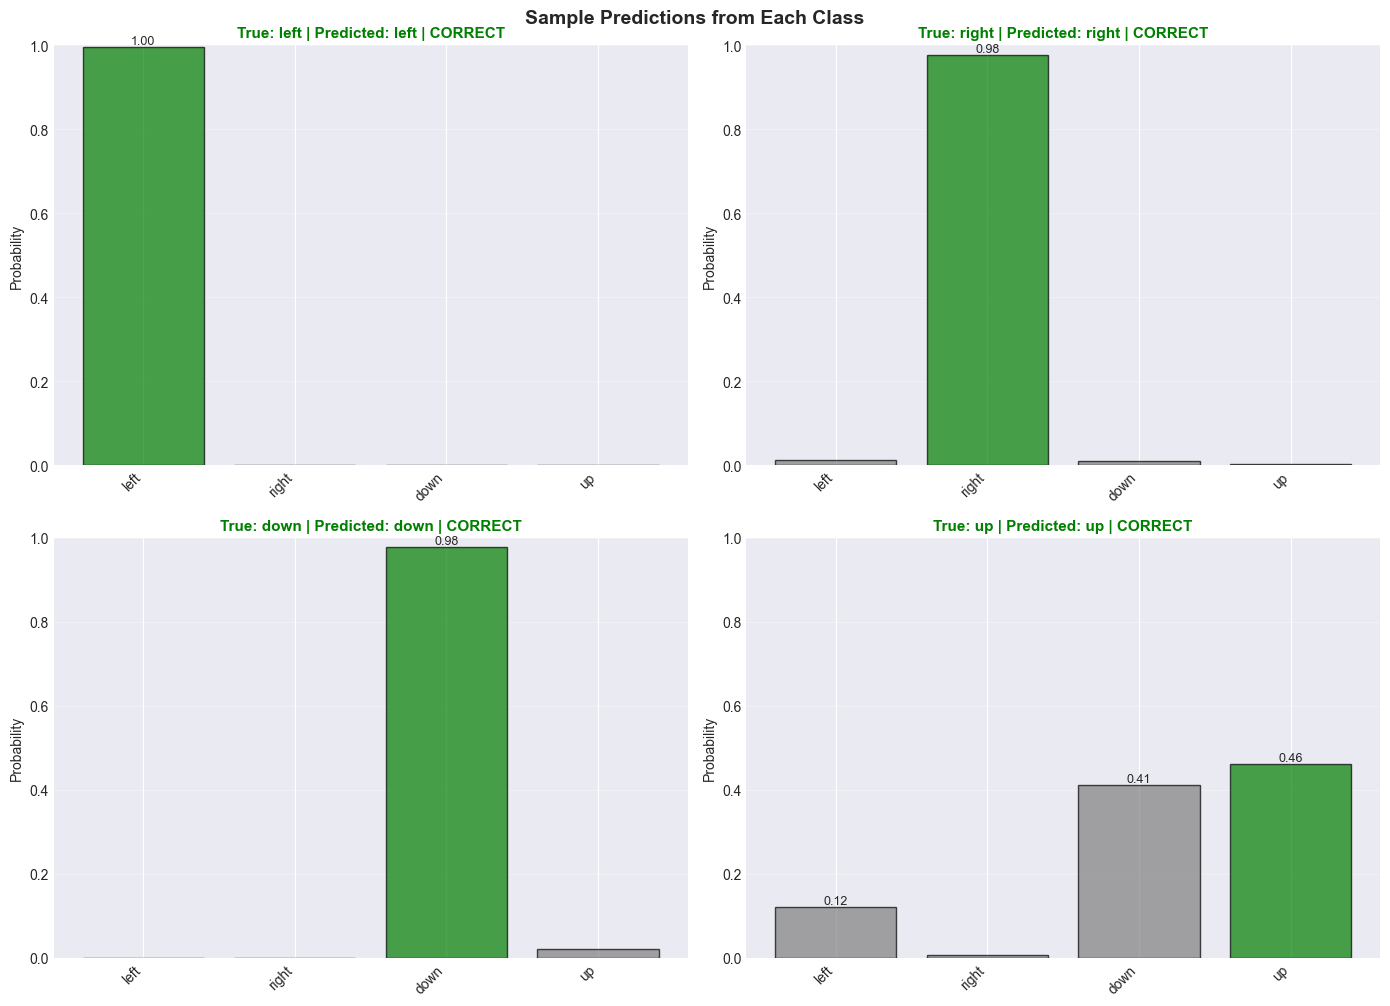

In [9]:
# Test one sample from each class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for class_idx in range(len(class_names)):
    # Get first sample of this class
    class_samples = np.where(y_val == class_idx)[0]
    
    if len(class_samples) == 0:
        axes[class_idx].text(0.5, 0.5, 'No samples', 
                            ha='center', va='center', fontsize=14)
        axes[class_idx].set_title(f'Class: {class_names[class_idx]}', 
                                  fontsize=12, fontweight='bold')
        continue
    
    sample_idx = class_samples[0]
    sample = X_val[sample_idx]
    
    # Predict
    predicted_class, probabilities = predict_single_sample(model, sample, device)
    
    # Plot probabilities
    colors = ['green' if i == predicted_class else 'gray' 
              for i in range(len(class_names))]
    bars = axes[class_idx].bar(range(len(class_names)), probabilities, 
                                color=colors, alpha=0.7, edgecolor='black')
    
    axes[class_idx].set_xticks(range(len(class_names)))
    axes[class_idx].set_xticklabels(class_names, rotation=45, ha='right')
    axes[class_idx].set_ylabel('Probability', fontsize=10)
    axes[class_idx].set_ylim([0, 1.0])
    axes[class_idx].grid(axis='y', alpha=0.3)
    
    # Title with result
    result = "CORRECT" if predicted_class == class_idx else "INCORRECT"
    color = 'green' if predicted_class == class_idx else 'red'
    axes[class_idx].set_title(
        f'True: {class_names[class_idx]} | Predicted: {class_names[predicted_class]} | {result}',
        fontsize=11, fontweight='bold', color=color
    )
    
    # Add value labels
    for bar, prob in zip(bars, probabilities):
        height = bar.get_height()
        if height > 0.05:
            axes[class_idx].text(bar.get_x() + bar.get_width()/2., height,
                                f'{prob:.2f}',
                                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Sample Predictions from Each Class', 
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

## 8. Interactive Sample Selection

Select and test specific samples interactively.

In [10]:
# Change this to test different samples
SAMPLE_INDEX = 0  # Try different indices: 0, 1, 2, ..., len(X_val)-1

if SAMPLE_INDEX >= len(X_val):
    print(f"Invalid index. Maximum index is {len(X_val)-1}")
else:
    sample = X_val[SAMPLE_INDEX]
    true_label = y_val[SAMPLE_INDEX]
    
    predicted_class, probabilities = predict_single_sample(model, sample, device)
    
    print(f"\nSample {SAMPLE_INDEX}:")
    print(f"  True label:    {class_names[true_label]}")
    print(f"  Predicted:     {class_names[predicted_class]}")
    print(f"  Confidence:    {probabilities[predicted_class]:.4f}")
    print(f"  Result:        {'CORRECT' if predicted_class == true_label else 'INCORRECT'}")
    print(f"\nAll class probabilities:")
    for name, prob in zip(class_names, probabilities):
        print(f"  {name:<15}: {prob:.4f}")


Sample 0:
  True label:    left
  Predicted:     left
  Confidence:    0.9968
  Result:        CORRECT

All class probabilities:
  left           : 0.9968
  right          : 0.0013
  down           : 0.0003
  up             : 0.0016


## 9. Model Inference Function for Production

A clean function for integrating the model into production systems.

In [11]:
def infer_motor_imagery(eeg_epoch: np.ndarray, 
                        model: nn.Module, 
                        device: torch.device,
                        class_names: list) -> dict:
    """
    Production-ready inference function for motor imagery classification.
    
    Args:
        eeg_epoch: EEG data (n_channels, n_timepoints)
        model: Trained EEGNet model
        device: torch device
        class_names: List of class names
    
    Returns:
        Dictionary with:
            - predicted_class: Class name
            - predicted_index: Class index (0-3)
            - confidence: Prediction confidence [0, 1]
            - all_probabilities: Dict of {class_name: probability}
    """
    # Validate input shape
    if eeg_epoch.ndim != 2:
        raise ValueError(f"Expected 2D array (channels, timepoints), got shape {eeg_epoch.shape}")
    
    # Prepare input
    input_tensor = torch.from_numpy(eeg_epoch).float().unsqueeze(0).unsqueeze(0).to(device)
    
    # Run inference
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1).cpu().numpy()[0]
        predicted_idx = probabilities.argmax()
    
    # Format results
    return {
        'predicted_class': class_names[predicted_idx],
        'predicted_index': int(predicted_idx),
        'confidence': float(probabilities[predicted_idx]),
        'all_probabilities': {name: float(prob) 
                             for name, prob in zip(class_names, probabilities)}
    }

# Test the function
test_sample = X_val[0]
result = infer_motor_imagery(test_sample, model, device, class_names)

print("\nProduction inference result:")
print(f"  Predicted class: {result['predicted_class']}")
print(f"  Confidence: {result['confidence']:.4f}")
print(f"  All probabilities: {result['all_probabilities']}")


Production inference result:
  Predicted class: left
  Confidence: 0.9968
  All probabilities: {'left': 0.9968299269676208, 'right': 0.0012938815634697676, 'down': 0.0002955853706225753, 'up': 0.0015807360177859664}


## 10. Summary

Model inference complete. Key capabilities:
- Single sample prediction with confidence scores
- Batch inference for multiple samples
- Visualization of predictions and probabilities
- Production-ready inference function

**Model Output Classes (Directional UI Control):**
- **left**: Left hand motor imagery → UI left action
- **right**: Right hand motor imagery → UI right action
- **down**: Foot motor imagery → UI down action
- **up**: Tongue motor imagery → UI up action
